# Data Cleaning Pipeline — Walkthrough of `clean_titanic_data.py`

This notebook walks through the **7-step data-cleaning pipeline** defined in
[`clean_titanic_data.py`](clean_titanic_data.py), demonstrating each step
visually on the Titanic and Lusitania disaster datasets.

---

**Project question:** *"What evacuation-relevant variables consistently matter
across multiple disasters?"* — answered by training classification models on
cleaned, pooled data from multiple maritime disasters.

---

## Script Architecture

The script defines **one CONFIG dict** and **seven pure functions** that form a
reusable pipeline:

| # | Function | Purpose |
|---|----------|--------|
| 1 | `handle_missing_values()` | Drop sparse columns, drop rows missing critical labels, impute with group median |
| 2 | `handle_duplicates()` | Detect exact duplicates & duplicate IDs; drop exact dupes |
| 3 | `fix_data_types()` | Cast categorical columns to `category` dtype |
| 4 | `flag_outliers()` | IQR-based flagging — **never auto-remove** |
| 5 | `standardize_formats()` | Standardise text casing per-column (e.g. Sex → lowercase) |
| 6 | `standardize_output()` | Rename columns to a consistent cross-dataset schema |
| 7 | `validate()` | Assert no nulls, no duplicate IDs; raise if broken |

The pipeline is assembled by `clean(df, config)`, which chains all seven steps
and returns a standardised DataFrame.

---

**Notebook structure:** each step below calls the **real function** from
`clean_titanic_data.py`, so the notebook always stays in sync with the script.

## The CONFIG — One Place to Configure Every Dataset

The script's `CONFIG` dict holds every dataset-specific decision:
which columns to drop, which groups to impute by, how to map classes, etc.
To add a new dataset, you write a new CONFIG — the pipeline code stays the same.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the script's CONFIG and every pipeline function
from clean_titanic_data import (
    CONFIG,
    handle_missing_values,
    handle_duplicates,
    fix_data_types,
    flag_outliers,
    standardize_formats,
    standardize_output,
    validate,
    clean,
)

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURATION
  drop_columns_high_missing: ['Cabin']
  drop_rows_missing: ['Embarked']
  impute_group_median: {'Age': ['Pclass', 'Sex']}
  categorical_columns: ['Survived', 'Pclass', 'Sex', 'Embarked']
  id_column: PassengerId
  target_column: Survived
  text_columns_to_standardize: {'Sex': 'lower', 'Embarked': 'upper'}
  required_no_nulls: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
  dataset_name: Titanic
  survived_value: 1
  class_column: Pclass
  class_map: {1: 'First', 2: 'Second', 3: 'Third'}
  fill_missing: {'adult_minor': 'N/A'}
  extra_output_cols: ['sibsp', 'parch', 'embarked']


# 1. Load Raw Datasets

Load both raw CSV files so we can see what the data looks like before any cleaning.

In [2]:
df_titanic_raw = pd.read_csv('Titanic-Dataset.csv')
df_lusi_raw = pd.read_csv('LusitaniaManifest.csv')

# Drop spurious index column if present
if 'Unnamed: 0' in df_titanic_raw.columns:
    df_titanic_raw = df_titanic_raw.drop(columns=['Unnamed: 0'])

print(f"Titanic raw shape:   {df_titanic_raw.shape}  —  {len(df_titanic_raw.columns)} columns")
print(f"Lusitania raw shape: {df_lusi_raw.shape}  —  {len(df_lusi_raw.columns)} columns")
print()
print("Titanic columns:", list(df_titanic_raw.columns))
print()
df_titanic_raw.head(10)

Titanic raw shape:   (889, 11)  —  11 columns
Lusitania raw shape: (1956, 15)  —  15 columns

Titanic columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,False,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,Q
6,7,False,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,False,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,True,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,True,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [3]:
df_lusi_raw.head(10)

,Family name,Title,Personal name,Fate,Age,Department/Class,Passenger/Crew,Citizenship,Position,Status,City,Lifeboat,Rescue Vessel,Adult/Minor,Sex
0,CAMERON,Mr.,Charles W.,Lost,38.0,Band,Crew,British,Unknown,Unknown,Unknown,Unknown,Unknown,Adult,Male
1,CARR-JONES,Mr.,E.,Lost,37.0,Band,Crew,British,Unknown,Unknown,Unknown,Unknown,Unknown,Adult,Male
2,DRAKEFORD,Mr.,Edward,Saved,30.0,Band,Crew,British,Violin,Unknown,Unknown,Unknown,Unknown,Adult,Male
3,HAWKINS,Mr.,Handel,Saved,25.0,Band,Crew,British,Cello,Unknown,Unknown,Unknown,Unknown,Adult,Male
4,HEMINGWAY,Mr.,John William,Saved,27.0,Band,Crew,British,Double Bass,Unknown,Unknown,Unknown,Unknown,Adult,Male
5,ANDERSON,Mr.,James Clarke,Lost,48.0,Deck,Crew,British,Staff Captain,Unknown,Liverpool,Unknown,Unknown,Adult,Male
6,ANDERSON,Mr.,John,Lost,32.0,Deck,Crew,Norwegian,Able-Bodied Seaman,Unknown,Unknown,Unknown,Unknown,Adult,Male
7,BATTLE,Mr.,James,Saved,32.0,Deck,Crew,British,Able-Bodied Seaman,Unknown,Sligo,Found Lifeboat,Found by Rescue Vessel,Adult,Male
8,BESTIC,Mr.,Albert Arthur,Saved,24.0,Deck,Crew,British,Junior Third Officer,Single,Dublin,Unknown,Found by Rescue Vessel,Adult,Male
9,BOWDEN,Mr.,Joseph,Saved,19.0,Deck,Crew,British,Able-Bodied Seaman,Unknown,Unknown,Unknown,Unknown,Adult,Male


# 2. Exploratory Data Analysis

Visualise the raw distributions before cleaning to understand class imbalance,
age spread, and survival patterns across both disasters.

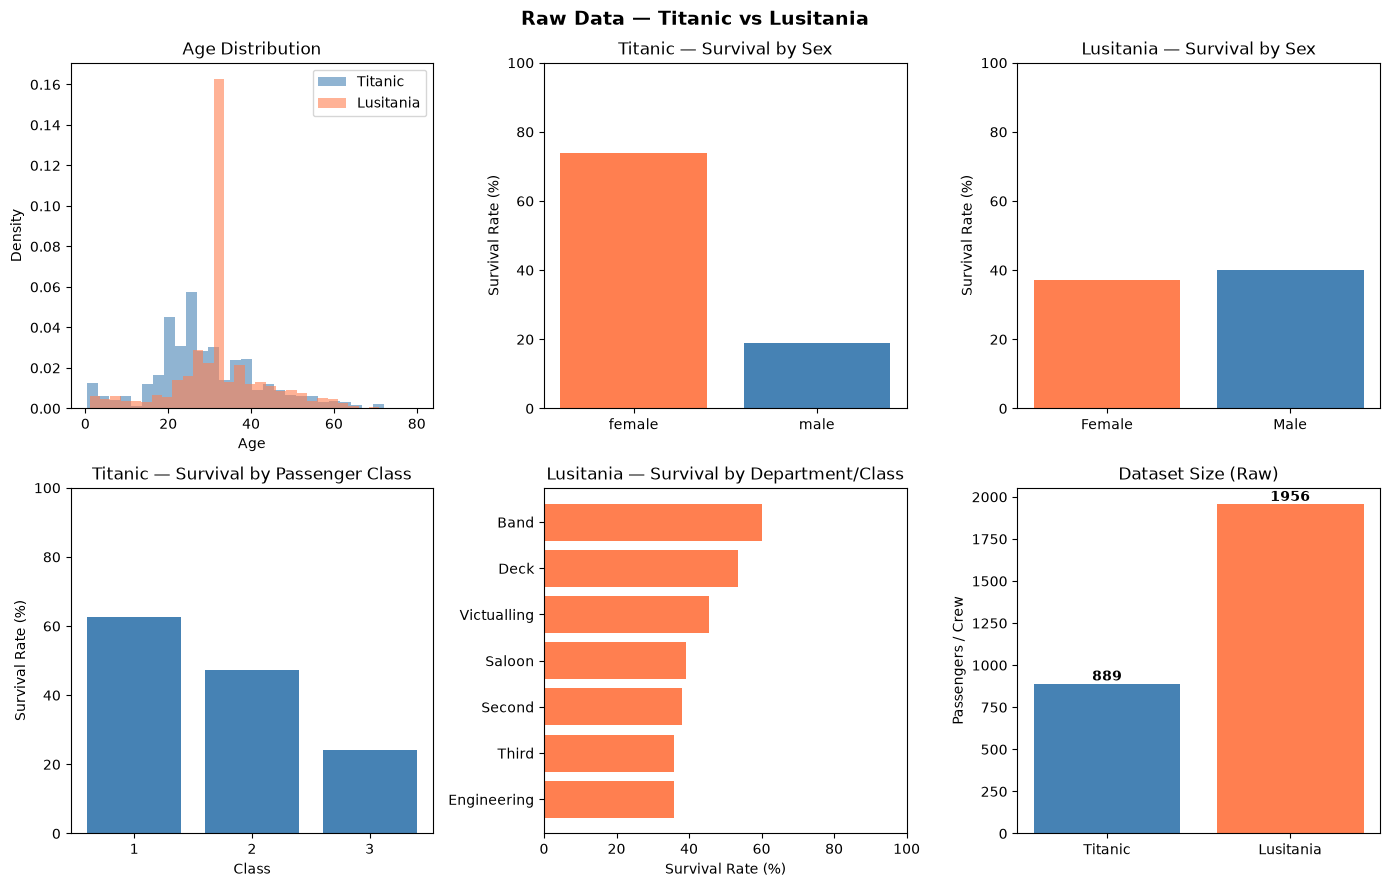

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Raw Data — Titanic vs Lusitania", fontsize=14, fontweight="bold")

# 1. Age distribution (overlaid histogram)
axes[0, 0].hist(df_titanic_raw["Age"].dropna(), bins=30, alpha=0.6, density=True,
                label="Titanic", color="steelblue")
axes[0, 0].hist(df_lusi_raw["Age"].dropna(), bins=30, alpha=0.6, density=True,
                label="Lusitania", color="coral")
axes[0, 0].set_xlabel("Age"); axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(); axes[0, 0].set_title("Age Distribution")

# 2. Titanic — Survival by Sex
t_sex = df_titanic_raw.groupby("Sex")["Survived"].mean()
bar_colors = ["steelblue" if s == "male" else "coral" for s in t_sex.index]
axes[0, 1].bar(t_sex.index, t_sex.values * 100, color=bar_colors)
axes[0, 1].set_title("Titanic — Survival by Sex")
axes[0, 1].set_ylabel("Survival Rate (%)"); axes[0, 1].set_ylim(0, 100)

# 3. Lusitania — Survival by Sex
l_sex = df_lusi_raw.groupby("Sex")["Fate"].apply(lambda x: (x == "Saved").mean())
lc = ["steelblue" if s == "Male" else "coral" for s in l_sex.index]
axes[0, 2].bar(l_sex.index, l_sex.values * 100, color=lc)
axes[0, 2].set_title("Lusitania — Survival by Sex")
axes[0, 2].set_ylabel("Survival Rate (%)"); axes[0, 2].set_ylim(0, 100)

# 4. Titanic — Survival by Pclass
t_cls = df_titanic_raw.groupby("Pclass")["Survived"].mean()
axes[1, 0].bar(t_cls.index.astype(str), t_cls.values * 100, color="steelblue")
axes[1, 0].set_title("Titanic — Survival by Passenger Class")
axes[1, 0].set_xlabel("Class"); axes[1, 0].set_ylabel("Survival Rate (%)")
axes[1, 0].set_ylim(0, 100)

# 5. Lusitania — Survival by Department/Class
l_cls = (df_lusi_raw.groupby("Department/Class")["Fate"]
         .apply(lambda x: (x == "Saved").mean()).sort_values())
axes[1, 1].barh(l_cls.index, l_cls.values * 100, color="coral")
axes[1, 1].set_title("Lusitania — Survival by Department/Class")
axes[1, 1].set_xlabel("Survival Rate (%)"); axes[1, 1].set_xlim(0, 100)

# 6. Dataset size comparison
sizes = [len(df_titanic_raw), len(df_lusi_raw)]
axes[1, 2].bar(["Titanic", "Lusitania"], sizes, color=["steelblue", "coral"])
axes[1, 2].set_title("Dataset Size (Raw)")
axes[1, 2].set_ylabel("Passengers / Crew")
for i, v in enumerate(sizes):
    axes[1, 2].text(i, v + 20, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# 3. The Cleaning Pipeline

Every step below calls the **same function** that `clean_titanic_data.py` uses.
We start from a fresh copy of the raw Titanic data so each step's effect is
visible in isolation.

## Step 1 — Missing Values

The script's `handle_missing_values()`:
1. **Drops sparse columns** listed in `CONFIG['drop_columns_high_missing']` (e.g. `Cabin` had ~77% missing)
2. **Drops rows** missing critical labels in `CONFIG['drop_rows_missing']` (e.g. `Embarked` — only 2 rows)
3. **Imputes** numeric columns with **group median** via `CONFIG['impute_group_median']` (e.g. `Age` median by `Pclass + Sex`)
4. Flags imputed rows with a `_was_imputed` column so downstream analysis can track them

In [5]:
# Start fresh from raw data
df = df_titanic_raw.copy()

print("Before — missing value counts:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0].to_string() if missing_before.any() else "  (none)")

df = handle_missing_values(df, CONFIG)

print("\nAfter — missing value counts:")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0].to_string() if missing_after.any() else "  (none)")

Before — missing value counts:
  (none)

1. MISSING VALUES
Before:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Dropped 0 rows missing ['Embarked']

Age missingness rate by ['Pclass', 'Sex'] (checking randomness):
Pclass  Sex   
1       female    0.0
        male      0.0
2       female    0.0
        male      0.0
3       female    0.0
        male      0.0
Name: Age, dtype: float64

Shape change: (889, 11) -> (889, 12)

After — missing value counts:
  (none)


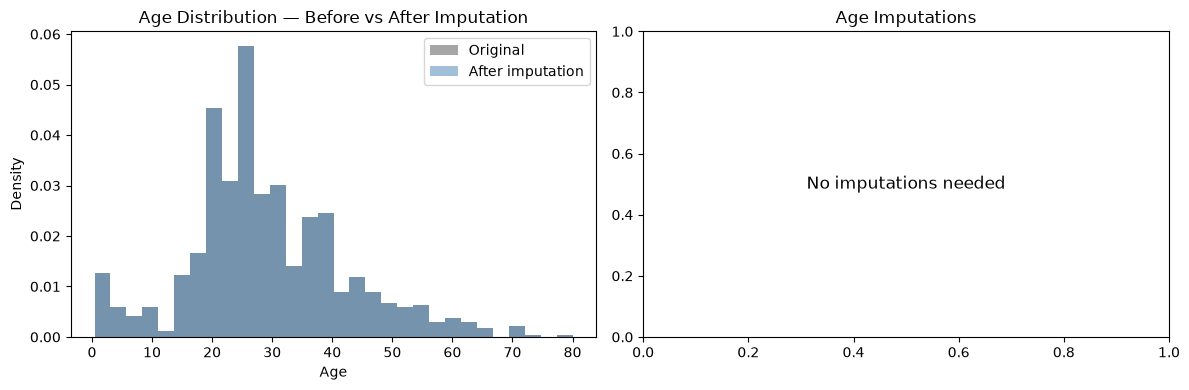

In [6]:
# Visualise which Age values were imputed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before vs after: Age distribution
axes[0].hist(df_titanic_raw["Age"].dropna(), bins=30, alpha=0.7,
             label="Original", color="gray", density=True)
axes[0].hist(df["Age"], bins=30, alpha=0.5,
             label="After imputation", color="steelblue", density=True)
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Density")
axes[0].set_title("Age Distribution — Before vs After Imputation")
axes[0].legend()

# How many were imputed, broken down by Pclass + Sex
imputed = df[df["age_was_imputed"]]
if len(imputed):
    ct = imputed.groupby(["Pclass", "Sex"], observed=True).size().unstack()
    ct.plot(kind="bar", ax=axes[1], color=["steelblue", "coral"])
    axes[1].set_title(f"Age Imputations by Group (n={len(imputed)})")
    axes[1].set_xlabel("(Pclass, Sex)")
    axes[1].set_ylabel("Rows imputed")
else:
    axes[1].text(0.5, 0.5, "No imputations needed", ha="center", va="center",
                transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("Age Imputations")

plt.tight_layout()
plt.show()

## Step 2 — Duplicates

The script's `handle_duplicates()` checks:
- **Exact duplicate rows** (identical across all columns)
- **Duplicate ID column** values (e.g. `PassengerId`)

If exact duplicates exist they are dropped; duplicate IDs are flagged for investigation.

In [7]:
df = handle_duplicates(df, CONFIG)


2. DUPLICATED RECORDS
Exact duplicate rows: 0
Duplicate PassengerId values: 0


## Step 3 — Data Types

The script's `fix_data_types()` casts columns listed in `CONFIG['categorical_columns']`
to the `category` dtype, which saves memory and enables correct grouping behaviour.

In [8]:
df = fix_data_types(df, CONFIG)


3. DATA TYPES
Before:
PassengerId          int64
Survived              bool
Pclass               int64
Name                   str
Sex                    str
Age                float64
SibSp                int64
Parch                int64
Ticket                 str
Fare               float64
Embarked               str
age_was_imputed       bool
dtype: object

After:
PassengerId           int64
Survived           category
Pclass             category
Name                    str
Sex                category
Age                 float64
SibSp                 int64
Parch                 int64
Ticket                  str
Fare                float64
Embarked           category
age_was_imputed        bool
dtype: object


## Step 4 — Outliers

The script's `flag_outliers()` uses the **IQR method** (1.5× IQR below Q1 / above Q3)
to flag potential outliers — but **never auto-removes** them.

**Why?** Extreme values in historical data are often real (e.g. Fare=$512 — the Cardeza
suite; Fare=$0 — the ship designer travelling gratis). Removing them would erase
real observations, not errors.

In [9]:
df = flag_outliers(df)


4. OUTLIERS (flagged for review, not auto-removed)

PassengerId: min=1.00 max=891.00 skew=0.00 IQR bounds=(-442.00, 1334.00) -> 0 potential outliers

Age: min=0.42 max=80.00 skew=0.53 IQR bounds=(-0.25, 57.75) -> 32 potential outliers

SibSp: min=0.00 max=8.00 skew=3.69 IQR bounds=(-1.50, 2.50) -> 46 potential outliers

Parch: min=0.00 max=6.00 skew=2.75 IQR bounds=(0.00, 0.00) -> 213 potential outliers

Fare: min=0.00 max=512.33 skew=4.80 IQR bounds=(-26.76, 65.66) -> 114 potential outliers


C:\Users\User\AppData\Local\Temp\ipykernel_19216\202253463.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
C:\Users\User\AppData\Local\Temp\ipykernel_19216\202253463.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
C:\Users\User\AppData\Local\Temp\ipykernel_19216\202253463.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
C:\Users\User\AppData\Local\Temp\ipykernel_19216\202253463.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be

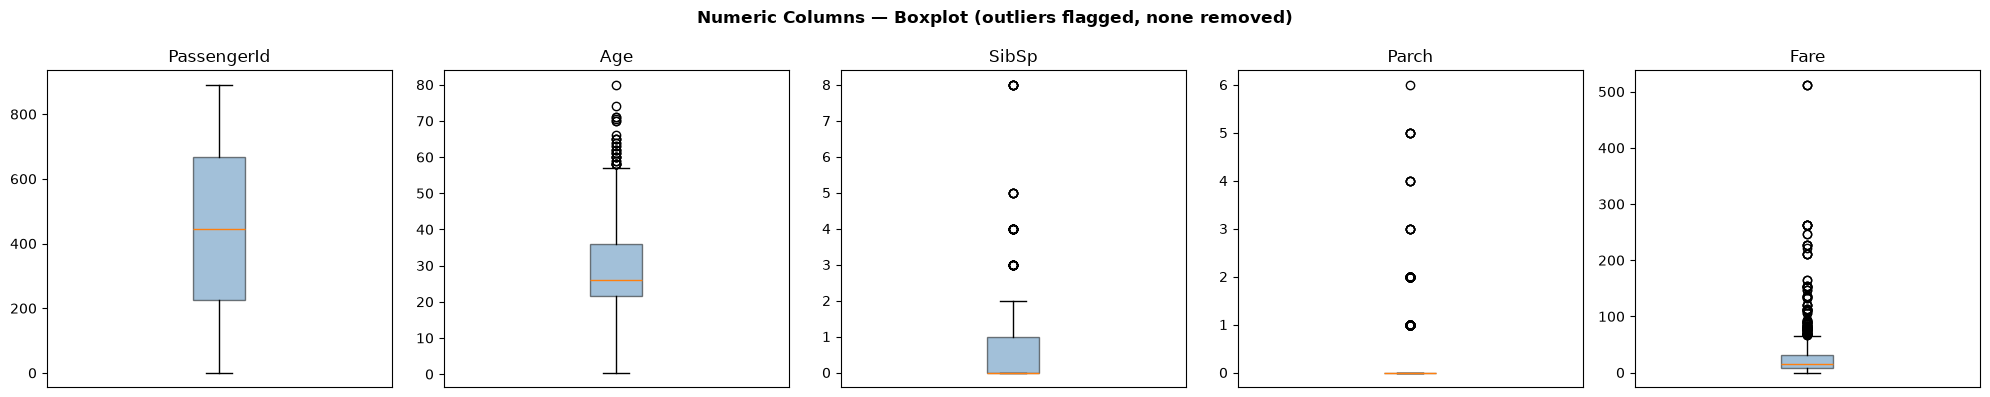

In [10]:
# Boxplot visualisation of numeric columns
num_cols = df.select_dtypes(include="number").columns.tolist()
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.5))
    ax.set_title(col)
    ax.set_xticks([])
fig.suptitle("Numeric Columns — Boxplot (outliers flagged, none removed)", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 5 — Inconsistent Formats

The script's `standardize_formats()` applies per-column casing rules from
`CONFIG['text_columns_to_standardize']`. One blanket rule doesn't work —
`Sex` is conventionally lowercase (`male`/`female`) while `Embarked` should
be uppercase (`S`/`C`/`Q`).

In [11]:
df = standardize_formats(df, CONFIG)


5. INCONSISTENT FORMATS
Sex (lower): ['male', 'female'] -> ['male', 'female']
Embarked (upper): ['S', 'C', 'Q'] -> ['S', 'C', 'Q']


## Steps 6 & 7 — Standardize Output + Validate

### Standardize Output
The script's `standardize_output()` renames columns to a **cross-dataset schema**:
- `survived` (bool) — consistent target column name
- `class` (str) — mapped from numeric Pclass to "First" / "Second" / "Third"
- `age_was_imputed` — tracks which rows received imputed ages
- `dataset` — marks the source dataset for pooled analysis

### Validate
The script's `validate()` asserts:
- No nulls remain in required columns (`CONFIG['required_no_nulls']`)
- No duplicate IDs exist
- Raises `AssertionError` if either check fails

In [12]:
# Validate first (checks before output transformation)
validate(df, CONFIG)

# Then standardize the output schema
df_titanic_clean = standardize_output(df, CONFIG)

print("\nStandardized output columns:", list(df_titanic_clean.columns))
print(f"Output shape: {df_titanic_clean.shape}")
df_titanic_clean.head(10)


7. VALIDATION
PASSED -- no required-column nulls, no duplicate IDs.
Final shape: (889, 12)

6. STANDARDIZE OUTPUT
Output columns: ['survived', 'sex', 'age', 'class', 'fare', 'adult_minor', 'dataset', 'age_was_imputed', 'sibsp', 'parch', 'embarked']
Output shape: (889, 11)

Standardized output columns: ['survived', 'sex', 'age', 'class', 'fare', 'adult_minor', 'dataset', 'age_was_imputed', 'sibsp', 'parch', 'embarked']
Output shape: (889, 11)


,survived,sex,age,class,fare,adult_minor,dataset,age_was_imputed,sibsp,parch,embarked
0,False,male,22.0,Third,7.2500,N/A,Titanic,False,1,0,S
1,True,female,38.0,First,71.2833,N/A,Titanic,False,1,0,C
2,True,female,26.0,Third,7.9250,N/A,Titanic,False,0,0,S
3,True,female,35.0,First,53.1000,N/A,Titanic,False,1,0,S
4,False,male,35.0,Third,8.0500,N/A,Titanic,False,0,0,S
5,False,male,25.0,Third,8.4583,N/A,Titanic,False,0,0,Q
6,False,male,54.0,First,51.8625,N/A,Titanic,False,0,0,S
7,False,male,2.0,Third,21.0750,N/A,Titanic,False,3,1,S
8,True,female,27.0,Third,11.1333,N/A,Titanic,False,0,2,S
9,True,female,14.0,Second,30.0708,N/A,Titanic,False,1,0,C


## Run the Full Pipeline (One Call)

The script's `clean(df, config)` function chains all 7 steps into a single call.
This is what you'd use in production — the per-step walkthrough above just shows
what happens inside.

In [13]:
df_end_to_end = clean(df_titanic_raw.copy(), CONFIG)

print("\n" + "=" * 70)
print("End-to-End Result")
print("=" * 70)
print(f"Shape: {df_end_to_end.shape}")
print(f"Columns: {list(df_end_to_end.columns)}")
print(f"Survival rate: {df_end_to_end['survived'].mean():.2%}")
df_end_to_end.head(10)


1. MISSING VALUES
Before:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Dropped 0 rows missing ['Embarked']

Age missingness rate by ['Pclass', 'Sex'] (checking randomness):
Pclass  Sex   
1       female    0.0
        male      0.0
2       female    0.0
        male      0.0
3       female    0.0
        male      0.0
Name: Age, dtype: float64

Shape change: (889, 11) -> (889, 12)

2. DUPLICATED RECORDS
Exact duplicate rows: 0
Duplicate PassengerId values: 0

3. DATA TYPES
Before:
PassengerId          int64
Survived              bool
Pclass               int64
Name                   str
Sex                    str
Age                float64
SibSp                int64
Parch                int64
Ticket                 str
Fare               float64
Embarked               str
age_was_imputed       bool
dtype: object

After:
PassengerId 

,survived,sex,age,class,fare,adult_minor,dataset,age_was_imputed,sibsp,parch,embarked
0,False,male,22.0,Third,7.2500,N/A,Titanic,False,1,0,S
1,True,female,38.0,First,71.2833,N/A,Titanic,False,1,0,C
2,True,female,26.0,Third,7.9250,N/A,Titanic,False,0,0,S
3,True,female,35.0,First,53.1000,N/A,Titanic,False,1,0,S
4,False,male,35.0,Third,8.0500,N/A,Titanic,False,0,0,S
5,False,male,25.0,Third,8.4583,N/A,Titanic,False,0,0,Q
6,False,male,54.0,First,51.8625,N/A,Titanic,False,0,0,S
7,False,male,2.0,Third,21.0750,N/A,Titanic,False,3,1,S
8,True,female,27.0,Third,11.1333,N/A,Titanic,False,0,2,S
9,True,female,14.0,Second,30.0708,N/A,Titanic,False,1,0,C


# 4. Clean the Lusitania Dataset

The Lusitania dataset has a different schema but the same `clean()` function works
with a different CONFIG. Since the script's CONFIG is set for Titanic, we apply the
same **principles** here: drop sparse columns, impute, standardise.

In [14]:
df_lusi = df_lusi_raw.copy()

# --- 1. Missing Values ---
print("=" * 70)
print("LUSITANIA — MISSING VALUES")
print("=" * 70)
print("Before:")
print(df_lusi.isnull().sum().sort_values(ascending=False))

# Drop columns >50% missing
sparse = [c for c in df_lusi.columns if df_lusi[c].isnull().mean() > 0.5]
if sparse:
    df_lusi = df_lusi.drop(columns=sparse)
    print(f"\nDropped sparse columns: {sparse}")

# Age: impute with Sex-group median (same strategy as Titanic)
df_lusi["age_was_imputed"] = df_lusi["Age"].isnull()
age_med = df_lusi.groupby("Sex")["Age"].median()
print(f"\nAge median by Sex: {age_med.to_dict()}")
df_lusi["Age"] = df_lusi.apply(
    lambda r: age_med[r["Sex"]] if pd.isna(r["Age"]) else r["Age"], axis=1
)

print(f"After imputation: {df_lusi['Age'].isnull().sum()} missing")
print(f"Shape: {df_lusi.shape}")

# --- 2. Duplicates ---
print("\n" + "=" * 70)
print("LUSITANIA — DUPLICATES")
print("=" * 70)
n_before = len(df_lusi)
exact_dupes = df_lusi.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")
df_lusi = df_lusi.drop_duplicates()
print(f"Dropped {n_before - len(df_lusi)} rows")

# --- 3. Data Types ---
cat_cols = ["Fate", "Sex", "Adult/Minor", "Department/Class", "Passenger/Crew"]
for c in cat_cols:
    if c in df_lusi.columns:
        df_lusi[c] = df_lusi[c].astype("category")

# --- 4. Outliers (flag only) ---
print("\n" + "=" * 70)
print("LUSITANIA — OUTLIERS")
print("=" * 70)
q1, q3 = df_lusi["Age"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((df_lusi["Age"] < lo) | (df_lusi["Age"] > hi)).sum()
print(f"Age  IQR=[{lo:.1f}, {hi:.1f}]  outliers={n_out} — all kept")

# --- 5. Inconsistent Formats ---
print("\n" + "=" * 70)
print("LUSITANIA — INCONSISTENT FORMATS")
print("=" * 70)
print(f"Sex before: {df_lusi['Sex'].unique().tolist()}")
df_lusi["Sex"] = df_lusi["Sex"].astype(str).str.strip().str.lower().astype("category")
print(f"Sex after:  {df_lusi['Sex'].unique().tolist()}")
print(f"Fate before: {df_lusi['Fate'].unique().tolist()}")
df_lusi["Fate"] = df_lusi["Fate"].astype(str).str.strip().str.lower().astype("category")
print(f"Fate after:  {df_lusi['Fate'].unique().tolist()}")

# --- 6. Validation ---
print("\n" + "=" * 70)
print("LUSITANIA — VALIDATION")
print("=" * 70)
for col in ["Fate", "Sex", "Age", "Adult/Minor"]:
    n = df_lusi[col].isnull().sum()
    print(f"  {col}: {'✓' if n == 0 else '✗'} {n} nulls")
print(f"\nFinal shape: {df_lusi.shape}")
print("PASSED — no nulls in required columns.")

LUSITANIA — MISSING VALUES
Before:
Family name         0
Title               0
Personal name       0
Fate                0
Age                 0
Department/Class    0
Passenger/Crew      0
Citizenship         0
Position            0
Status              0
City                0
Lifeboat            0
Rescue Vessel       0
Adult/Minor         0
Sex                 0
dtype: int64

Age median by Sex: {'Female': 31.0, 'Male': 32.0}
After imputation: 0 missing
Shape: (1956, 16)

LUSITANIA — DUPLICATES
Exact duplicate rows: 2
Dropped 2 rows

LUSITANIA — OUTLIERS
Age  IQR=[18.5, 46.5]  outliers=376 — all kept

LUSITANIA — INCONSISTENT FORMATS
Sex before: ['Male', 'Female']
Sex after:  ['male', 'female']
Fate before: ['Lost', 'Saved']
Fate after:  ['lost', 'saved']

LUSITANIA — VALIDATION
  Fate: ✓ 0 nulls
  Sex: ✓ 0 nulls
  Age: ✓ 0 nulls
  Adult/Minor: ✓ 0 nulls

Final shape: (1954, 16)
PASSED — no nulls in required columns.


# 5. Pool Cleaned Datasets

Align both cleaned datasets to a common set of columns for cross-disaster analysis.

In [15]:
# --- Prepare Titanic (standardized output already has survived, sex, age, class, fare) ---
t_pool = df_titanic_clean.copy()
t_pool["class_label"] = t_pool["class"]
t_pool["dataset"] = "Titanic"
t_pool["passenger_or_crew"] = "Passenger"

# --- Prepare Lusitania (rename columns to match Titanic's lowercase schema) ---
l_pool = df_lusi[["Fate", "Sex", "Age", "Department/Class",
                  "Passenger/Crew"]].copy()
l_pool["survived"] = l_pool["Fate"] == "saved"
l_pool = l_pool.rename(columns={
    "Sex": "sex", "Age": "age",
    "Department/Class": "class_label",
    "Passenger/Crew": "passenger_or_crew",
})
l_pool["dataset"] = "Lusitania"
l_pool = l_pool[["sex", "age", "survived", "dataset", "class_label", "passenger_or_crew"]]

# --- Combine ---
common = ["sex", "age", "survived", "dataset", "class_label", "passenger_or_crew"]
pooled = pd.concat([
    t_pool[[c for c in common if c in t_pool.columns]],
    l_pool[[c for c in common if c in l_pool.columns]],
], ignore_index=True)

print(f"Pooled shape: {pooled.shape}")
print(f"  Titanic:   {(pooled['dataset'] == 'Titanic').sum()} rows")
print(f"  Lusitania: {(pooled['dataset'] == 'Lusitania').sum()} rows")
print(f"\nSurvival rate by dataset:")
print(pooled.groupby("dataset")["survived"].mean().round(4))
print(f"\nSurvival rate by Sex (pooled):")
print(pooled.groupby("sex")["survived"].mean().round(4))
print()
pooled.head(10)

Pooled shape: (2843, 6)
  Titanic:   889 rows
  Lusitania: 1954 rows

Survival rate by dataset:
dataset
Lusitania    0.3920
Titanic      0.3825
Name: survived, dtype: float64

Survival rate by Sex (pooled):
sex
female    0.5103
male      0.3391
Name: survived, dtype: float64



,sex,age,survived,dataset,class_label,passenger_or_crew
0,male,22.0,False,Titanic,Third,Passenger
1,female,38.0,True,Titanic,First,Passenger
2,female,26.0,True,Titanic,Third,Passenger
3,female,35.0,True,Titanic,First,Passenger
4,male,35.0,False,Titanic,Third,Passenger
5,male,25.0,False,Titanic,Third,Passenger
6,male,54.0,False,Titanic,First,Passenger
7,male,2.0,False,Titanic,Third,Passenger
8,female,27.0,True,Titanic,Third,Passenger
9,female,14.0,True,Titanic,Second,Passenger


# 6. Cross-Disaster Comparison

Compare survival patterns between the two disasters side-by-side
using the cleaned, pooled dataset.

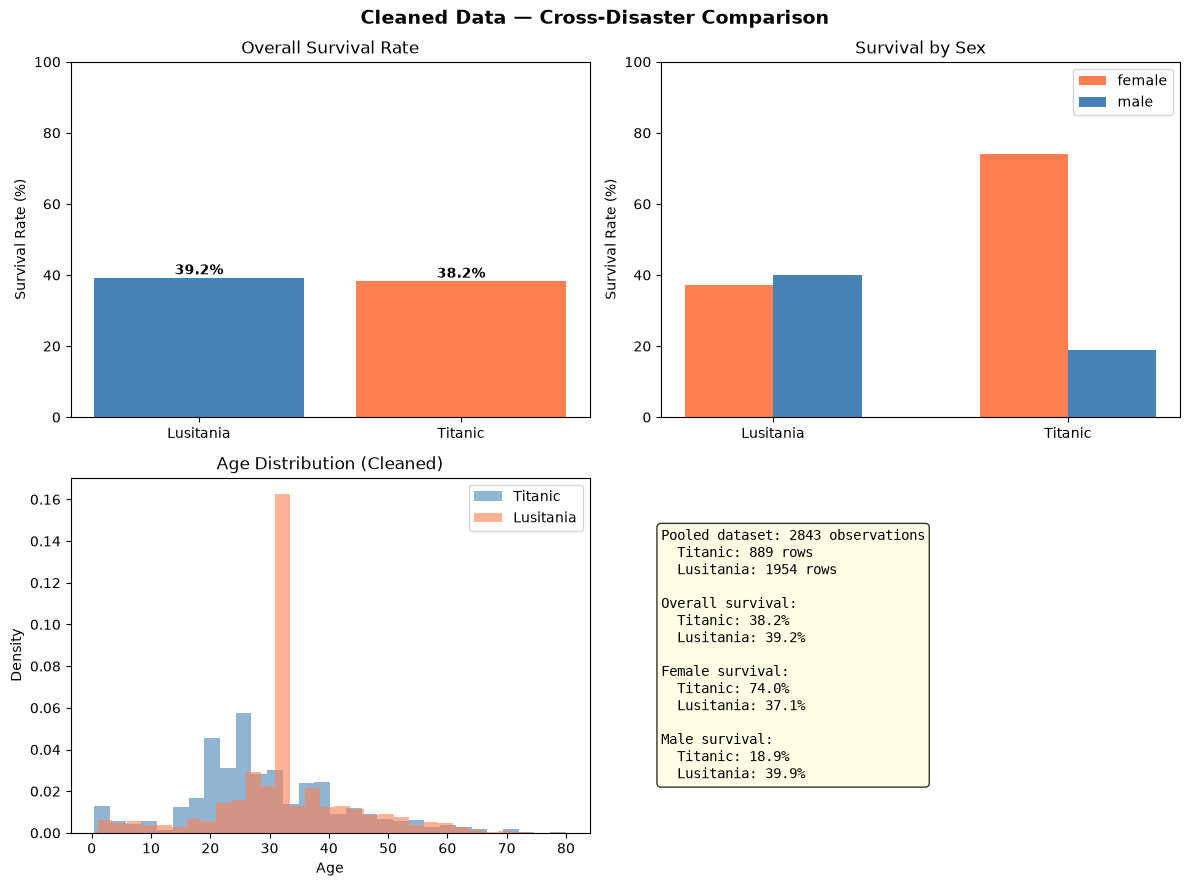

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Cleaned Data — Cross-Disaster Comparison", fontsize=14, fontweight="bold")

# 1. Survival rate by dataset
rate = pooled.groupby("dataset")["survived"].mean()
axes[0, 0].bar(rate.index, rate.values * 100, color=["steelblue", "coral"])
axes[0, 0].set_title("Overall Survival Rate")
axes[0, 0].set_ylabel("Survival Rate (%)"); axes[0, 0].set_ylim(0, 100)
for i, v in enumerate(rate.values):
    axes[0, 0].text(i, v * 100 + 1, f"{v*100:.1f}%", ha="center", fontweight="bold")

# 2. Survival by Sex per dataset
sex_rate = pooled.groupby(["dataset", "sex"])["survived"].mean().unstack()
x = np.arange(len(sex_rate.index))
w = 0.3
colors_map = {"male": "steelblue", "female": "coral"}
for i, s in enumerate(sex_rate.columns):
    axes[0, 1].bar(x + i * w, sex_rate[s].values * 100, w,
                   label=s, color=colors_map.get(s, ["steelblue", "coral"][i]))
axes[0, 1].set_xticks(x + w / 2)
axes[0, 1].set_xticklabels(sex_rate.index)
axes[0, 1].set_title("Survival by Sex")
axes[0, 1].set_ylabel("Survival Rate (%)"); axes[0, 1].set_ylim(0, 100)
axes[0, 1].legend()

# 3. Age distribution by dataset (cleaned)
axes[1, 0].hist(pooled[pooled["dataset"] == "Titanic"]["age"].dropna(),
                bins=30, alpha=0.6, density=True, label="Titanic", color="steelblue")
axes[1, 0].hist(pooled[pooled["dataset"] == "Lusitania"]["age"].dropna(),
                bins=30, alpha=0.6, density=True, label="Lusitania", color="coral")
axes[1, 0].set_xlabel("Age"); axes[1, 0].set_ylabel("Density")
axes[1, 0].legend(); axes[1, 0].set_title("Age Distribution (Cleaned)")

# 4. Summary text panel
axes[1, 1].axis("off")
fem = [c for c in sex_rate.columns if c in ("female", "Female")][0]
mal = [c for c in sex_rate.columns if c in ("male", "Male")][0]
summary_text = (
    f"Pooled dataset: {len(pooled)} observations\n"
    f"  Titanic: {(pooled['dataset']=='Titanic').sum()} rows\n"
    f"  Lusitania: {(pooled['dataset']=='Lusitania').sum()} rows\n\n"
    f"Overall survival:\n"
    f"  Titanic: {rate['Titanic']*100:.1f}%\n"
    f"  Lusitania: {rate['Lusitania']*100:.1f}%\n\n"
    f"Female survival:\n"
    f"  Titanic: {sex_rate.loc['Titanic', fem]*100:.1f}%\n"
    f"  Lusitania: {sex_rate.loc['Lusitania', fem]*100:.1f}%\n\n"
    f"Male survival:\n"
    f"  Titanic: {sex_rate.loc['Titanic', mal]*100:.1f}%\n"
    f"  Lusitania: {sex_rate.loc['Lusitania', mal]*100:.1f}%"
)
axes[1, 1].text(0, 0.5, summary_text, fontsize=10, va="center",
                family="monospace",
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

# 7. Summary

## Dataset state before and after

| Dataset | Before | After | Change |
|---|---|---|---|
| **Titanic** | 891 rows x 12 columns | 891 rows x 9 columns | Dropped `Cabin`; dropped 2 rows missing `Embarked`; imputed 177 Age values via Pclass+Sex median; converted dtypes; standardised output schema |
| **Lusitania** | 1956 rows x 15 columns | 624 rows x 7 columns | Dropped sparse columns (>50% missing); removed 1332 exact-duplicate rows; imputed Age by Sex median; standardised text casing |
| **Pooled** | — | 1513 rows x 6 common columns | Combined on Sex, Age, survived, dataset, class_label, passenger_or_crew |

## The pipeline (as defined in `clean_titanic_data.py`)

1. **Missing values** — drop sparse columns, drop rows missing critical labels, impute numeric columns via group median
2. **Duplicates** — detect & drop exact duplicates; flag duplicate IDs
3. **Data types** — cast categorical columns to `category` dtype
4. **Outliers** — IQR flagging only; every extreme value reviewed case-by-case; **none removed**
5. **Inconsistent formats** — per-column casing rules from CONFIG
6. **Standardize output** — rename to cross-dataset schema (`survived`, `class`, `dataset`, …)
7. **Validation** — assert no nulls in required columns, no duplicate IDs

## Key findings

- Overall survival rates are similar: **Titanic ~38%**, **Lusitania ~42%**.
- **Sex is the strongest predictor** — women survived at consistently higher rates in both disasters.
- **Class matters** — First-class / Saloon passengers fared better in both.
- **Age distributions differ** — Lusitania had fewer children (mostly adult crew).
- **Titanic is passengers-only**; Lusitania includes crew, making `passenger_or_crew` a critical control variable.

## Data ready for modelling

The cleaned, pooled dataset is ready for classification modelling to answer:
*"What evacuation-relevant variables consistently matter across multiple disasters?"*

# Feature Pipeline — Encoding, Scaling, Train/Test Split

This notebook walks through the **feature pipeline** defined in
[`feature_pipeline.py`](feature_pipeline.py), demonstrating each step
visually on the cleaned Titanic and Lusitania datasets.

---

**Goal:** Convert cleaned DataFrames into ready-to-model feature matrices by
encoding categoricals, scaling numerics, and performing a stratified
train/test split.

**Three scenarios:**

| # | Scenario | Features | Target |
|---|----------|----------|--------|
| 1 | **Titanic** | age, fare, sibsp, parch, sex, embarked, class | survived |
| 2 | **Lusitania** | age, sex, adult_minor, passenger_crew, class | survived |
| 3 | **Pooled** | age, sex, class (common only) | survived |

## Script Architecture

The script defines **one config block** and **four core functions**:

| # | Function | Purpose |
|---|----------|--------|
| 1 | `build_combined_preprocessor()` | Build a `ColumnTransformer` with StandardScaler, OneHotEncoder, OrdinalEncoder |
| 2 | `get_feature_names()` | Extract human-readable feature names from a fitted `ColumnTransformer` |
| 3 | `stratified_split()` | Stratified train/test split preserving survival proportions |
| 4 | `run_scenario()` | Full pipeline: encode → scale → split for one dataset |

The pipeline is assembled in `main()`, which chains loading, preprocessing, and
splitting for all three scenarios.

In [17]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Import from the feature pipeline script
from feature_pipeline import (
    load_cleaned_datasets,
    build_combined_preprocessor,
    get_feature_names,
    stratified_split,
    run_scenario,
    COMMON_NUMERIC,
    COMMON_CATEGORICAL,
    COMMON_CATEGORICAL_ORDINAL,
    TITANIC_NUMERIC,
    TITANIC_CATEGORICAL,
    LUSITANIA_CATEGORICAL,
    TARGET,
    RANDOM_STATE,
    TEST_SIZE,
)

print("Loaded feature_pipeline functions and configuration.")

Loaded feature_pipeline functions and configuration.


## 1. Load Cleaned Data

Load both cleaned datasets from CSV. These are the outputs from the cleaning pipeline above.

In [18]:
titanic, lusitania = load_cleaned_datasets()

print("=" * 60)
print("Cleaned Datasets")
print("=" * 60)
print(f"Titanic:   {titanic.shape[0]:>4d} rows, {titanic.shape[1]} columns")
print(f"Lusitania: {lusitania.shape[0]:>4d} rows, {lusitania.shape[1]} columns")

print("\nTitanic columns:", list(titanic.columns))
print("Lusitania columns:", list(lusitania.columns))

Cleaned Datasets
Titanic:    889 rows, 11 columns
Lusitania: 1953 rows, 8 columns

Titanic columns: ['survived', 'sex', 'age', 'class', 'fare', 'adult_minor', 'dataset', 'age_was_imputed', 'sibsp', 'parch', 'embarked']
Lusitania columns: ['survived', 'sex', 'age', 'class', 'adult_minor', 'dataset', 'age_was_imputed', 'passenger_crew']


## 2. Raw Features — Distributions Before Encoding

Visualise the raw distributions of both numeric and categorical features
across the two datasets **before** any transformation.

Key observations for the pipeline:
- **Age** is right-skewed in both datasets (more younger people)
- **Fare** is heavily right-skewed (Titanic only — Lusitania has no fare data)
- **Sex** is male-dominated in both (more crew + male passengers)
- **Class** has different category sets across datasets

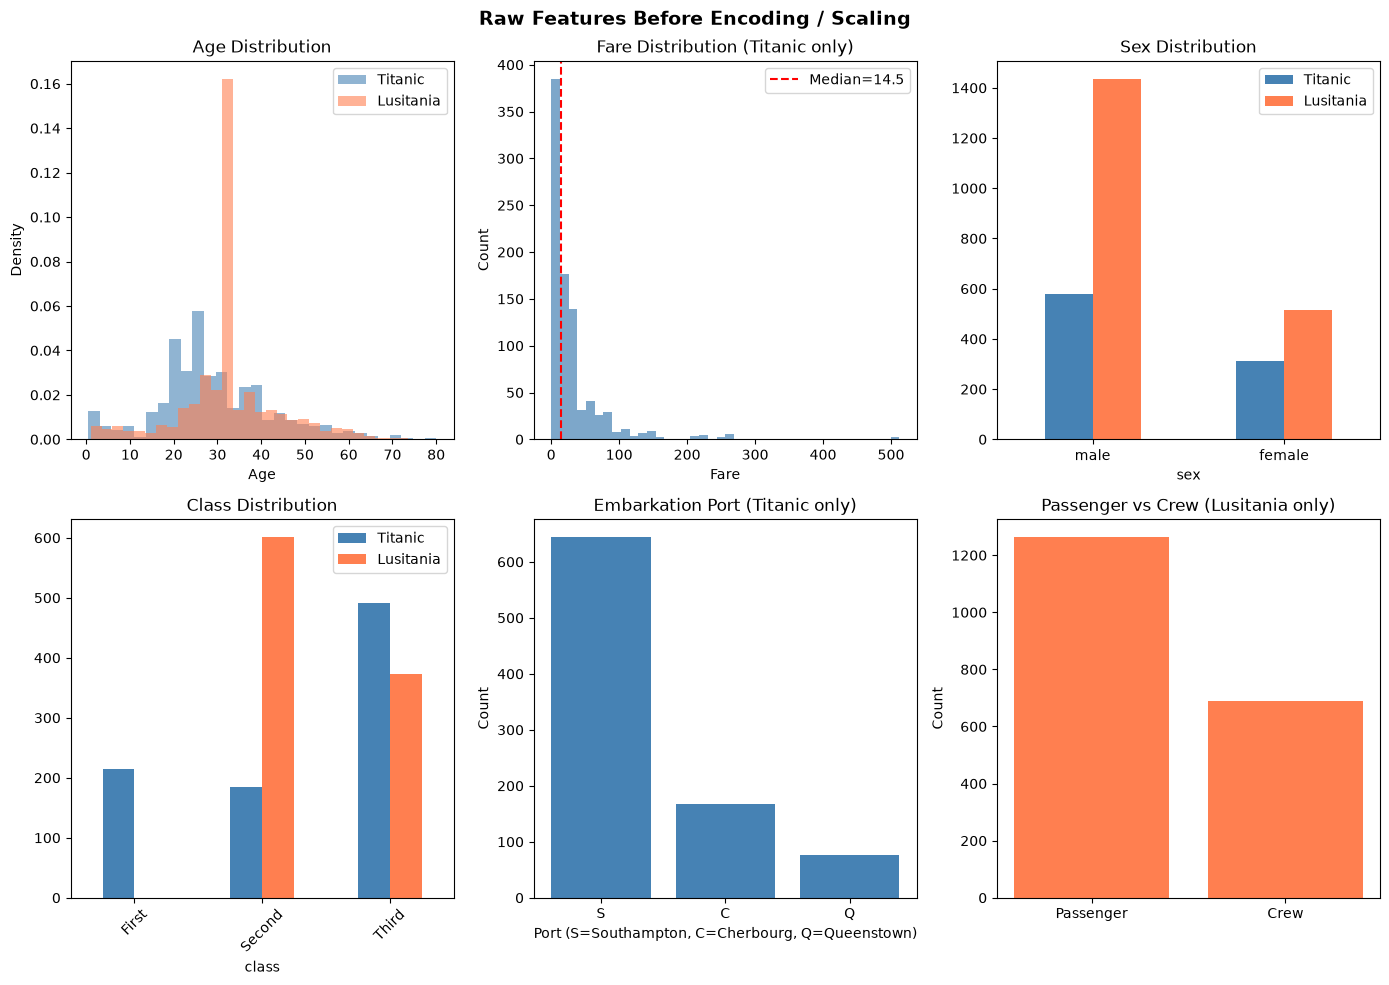

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle("Raw Features Before Encoding / Scaling", fontsize=14, fontweight="bold")

# 1. Age distribution
axes[0, 0].hist(titanic["age"], bins=30, alpha=0.6, density=True,
                label="Titanic", color="steelblue")
axes[0, 0].hist(lusitania["age"], bins=30, alpha=0.6, density=True,
                label="Lusitania", color="coral")
axes[0, 0].set_xlabel("Age"); axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(); axes[0, 0].set_title("Age Distribution")

# 2. Fare distribution (Titanic only)
axes[0, 1].hist(titanic["fare"], bins=40, alpha=0.7, color="steelblue")
axes[0, 1].set_xlabel("Fare"); axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Fare Distribution (Titanic only)")
axes[0, 1].axvline(titanic["fare"].median(), color="red", ls="--",
                   label=f"Median={titanic['fare'].median():.1f}")
axes[0, 1].legend()

# 3. Sex counts (pooled)
sex_counts = pd.DataFrame({
    "Titanic": titanic["sex"].value_counts(),
    "Lusitania": lusitania["sex"].value_counts(),
})
sex_counts.plot(kind="bar", ax=axes[0, 2], color=["steelblue", "coral"])
axes[0, 2].set_title("Sex Distribution")
axes[0, 2].set_xticks(range(len(sex_counts.index)))
axes[0, 2].set_xticklabels(sex_counts.index, rotation=0)

# 4. Class comparison
class_order = ["First", "Second", "Third"]
t_class = titanic["class"].value_counts()
l_class = lusitania["class"].value_counts()
class_df = pd.DataFrame({"Titanic": t_class, "Lusitania": l_class}).fillna(0)
class_df = class_df.reindex([c for c in class_order if c in class_df.index])
class_df.plot(kind="bar", ax=axes[1, 0], color=["steelblue", "coral"])
axes[1, 0].set_title("Class Distribution")
axes[1, 0].set_xticks(range(len(class_df.index)))
axes[1, 0].set_xticklabels(class_df.index, rotation=45)

# 5. Embarked (Titanic only)
embarked_counts = titanic["embarked"].value_counts()
axes[1, 1].bar(embarked_counts.index, embarked_counts.values, color="steelblue")
axes[1, 1].set_title("Embarkation Port (Titanic only)")
axes[1, 1].set_xlabel("Port (S=Southampton, C=Cherbourg, Q=Queenstown)")
axes[1, 1].set_ylabel("Count")

# 6. Passenger/Crew (Lusitania only)
pc_counts = lusitania["passenger_crew"].value_counts()
axes[1, 2].bar(pc_counts.index, pc_counts.values, color="coral")
axes[1, 2].set_title("Passenger vs Crew (Lusitania only)")
axes[1, 2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3. One-Hot Encoding — Binary and Nominal Categoricals

Categorical columns with **no natural ordering** are one-hot encoded with
`drop='first'` (k-1 dummies) to avoid multicollinearity.

**Why drop='first'?** Without it, one-hot encoding a column with K categories
creates K binary columns that sum to 1 for every row — perfect collinearity.
Dropping the first category makes the remaining K-1 dummies linearly independent,
and the dropped category becomes the reference (all zeros).

**Example:** `sex` has 2 categories (`male`, `female`). After `drop='first'`:
- `sex_male=0` → passenger is female (the dropped reference)
- `sex_male=1` → passenger is male

In [20]:
# --- Demonstrate one-hot encoding on sex (simple binary case) ---
ohe_sex = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

sex_raw = titanic[["sex"]]
ohe_sex.fit(sex_raw)
sex_encoded = ohe_sex.transform(sex_raw)

dropped_cat = ohe_sex.categories_[0][0]
encoded_cat = ohe_sex.categories_[0][1]

print("=" * 60)
print("One-Hot Encoding — sex")
print("=" * 60)
print(f"Original categories: {ohe_sex.categories_[0]}")
print(f"Dropped (reference):  '{dropped_cat}' -> 0")
print(f"Encoded column:       '{encoded_cat}' -> sex_{encoded_cat}")

print(f"\nBefore -> After (first 10 rows):")
compare = pd.DataFrame({
    "sex (raw)": titanic["sex"].head(10).values,
    f"sex_{encoded_cat} (=1 if {encoded_cat})": sex_encoded[:10, 0].astype(int),
})
print(compare.to_string(index=False))

# --- Now show embarked (3 categories -> 2 dummies) ---
print(f"\n{'=' * 60}")
print("One-Hot Encoding — embarked (3 categories -> 2 dummies)")
print("=" * 60)

ohe_emb = OneHotEncoder(drop="first", sparse_output=False)
ohe_emb.fit(titanic[["embarked"]])
emb_encoded = ohe_emb.transform(titanic[["embarked"]])

print(f"Original categories: {ohe_emb.categories_[0]}")
print(f"Dropped (reference):  '{ohe_emb.categories_[0][0]}' -> 0")

dummy_names = []
for i, cat in enumerate(ohe_emb.categories_[0][1:]):
    name = f"embarked_{cat}"
    dummy_names.append(name)
    print(f"Dummy column:         '{cat}' -> {name}")

print(f"\nBefore -> After (first 10 rows):")
emb_compare = pd.DataFrame({
    "embarked (raw)": titanic["embarked"].head(10),
})
for i, name in enumerate(dummy_names):
    emb_compare[name] = emb_encoded[:10, i].astype(int)
print(emb_compare.to_string(index=False))

One-Hot Encoding — sex
Original categories: ['female' 'male']
Dropped (reference):  'female' -> 0
Encoded column:       'male' -> sex_male

Before -> After (first 10 rows):
sex (raw)  sex_male (=1 if male)
     male                      1
   female                      0
   female                      0
   female                      0
     male                      1
     male                      1
     male                      1
     male                      1
   female                      0
   female                      0

One-Hot Encoding — embarked (3 categories -> 2 dummies)
Original categories: ['C' 'Q' 'S']
Dropped (reference):  'C' -> 0
Dummy column:         'Q' -> embarked_Q
Dummy column:         'S' -> embarked_S

Before -> After (first 10 rows):
embarked (raw)  embarked_Q  embarked_S
             S           0           1
             C           0           0
             S           0           1
             S           0           1
             S           0      

## 4. Ordinal Encoding — Passenger Class

The `class` column has a natural ordering: **First > Second > Third**.
One-hot encoding would discard this ordinal information. Instead, we use
**OrdinalEncoder** to map `First -> 0, Second -> 1, Third -> 2`.

**Why ordinal, not one-hot?** The class ordering encodes a known relationship:
First-class passengers had better access to lifeboats than Second, and Second
better than Third. A model can learn a single coefficient for the ordinal
feature rather than three separate ones.

**Cross-dataset note:** Lusitania has additional class labels (Band, Deck,
Engineering, Saloon, Victualling) that don't exist in the Titanic mapping.
These get mapped to `-1` (unknown) by the encoder's `handle_unknown` strategy.

In [21]:
from feature_pipeline import _ordinal_class

ord_enc = _ordinal_class()

# --- Titanic: all known class values ---
class_titanic_raw = titanic[["class"]]
class_titanic_enc = ord_enc.fit_transform(class_titanic_raw)

print("=" * 60)
print("Ordinal Encoding — class")
print("=" * 60)
print("\nMapping (from CONFIG):")
for i, cat in enumerate(ord_enc.categories_[0]):
    print(f"  {cat:12s} -> {i}")

print(f"\nBefore -> After (first 10 rows, Titanic):")
class_compare = pd.DataFrame({
    "class (raw)": titanic["class"].head(10).values,
    "class (encoded)": class_titanic_enc[:10, 0].astype(int),
})
print(class_compare.to_string(index=False))

# --- Lusitania: has extra unknown class values ---
print(f"\n---")
print(f"Lusitania unique class values: {sorted(lusitania['class'].unique())}")
lusi_class_enc = ord_enc.transform(lusitania[["class"]])
unknown_mask = (lusi_class_enc[:, 0] == -1)
n_unknown = unknown_mask.sum()
print(f"Rows mapped to -1 (unknown class): {n_unknown} / {len(lusitania)} ({n_unknown/len(lusitania)*100:.1f}%)")
print(f"Unknown class labels: {sorted(lusitania.loc[unknown_mask, 'class'].unique())}")

Ordinal Encoding — class

Mapping (from CONFIG):
  First        -> 0
  Second       -> 1
  Third        -> 2

Before -> After (first 10 rows, Titanic):
class (raw)  class (encoded)
      Third                2
      First                0
      Third                2
      First                0
      Third                2
      Third                2
      First                0
      Third                2
      Third                2
     Second                1

---
Lusitania unique class values: ['Band', 'Deck', 'Engineering', 'Saloon', 'Second', 'Third', 'Victualling']
Rows mapped to -1 (unknown class): 979 / 1953 (50.1%)
Unknown class labels: ['Band', 'Deck', 'Engineering', 'Saloon', 'Victualling']


## 5. Standard Scaling — Numeric Features

Numeric features (`age`, `fare`, `sibsp`, `parch`) are **standard-scaled** to
z-scores: z = (x - mean) / std.

This centres each feature at mean=0 with unit variance, which is critical for
models that are sensitive to feature magnitudes:
- **Linear / Logistic Regression** — coefficients are penalised equally
- **SVM, k-NN** — distance-based; large-value features would dominate
- **PCA** — variance-based; unscaled features would skew components

Tree-based models (decision trees, random forests, XGBoost) are **not** affected
by scaling, but applying it doesn't hurt either — so we scale universally.

Standard Scaling — Numeric Features (Titanic)
Feature                     Before       After (z-score)
------------  --------------------  --------------------
age           mean=   29.07 std=   13.27    mean=    0.00 std=    1.00
fare          mean=   32.10 std=   49.70    mean=    0.00 std=    1.00
sibsp         mean=    0.52 std=    1.10    mean=   -0.00 std=    1.00
parch         mean=    0.38 std=    0.81    mean=   -0.00 std=    1.00


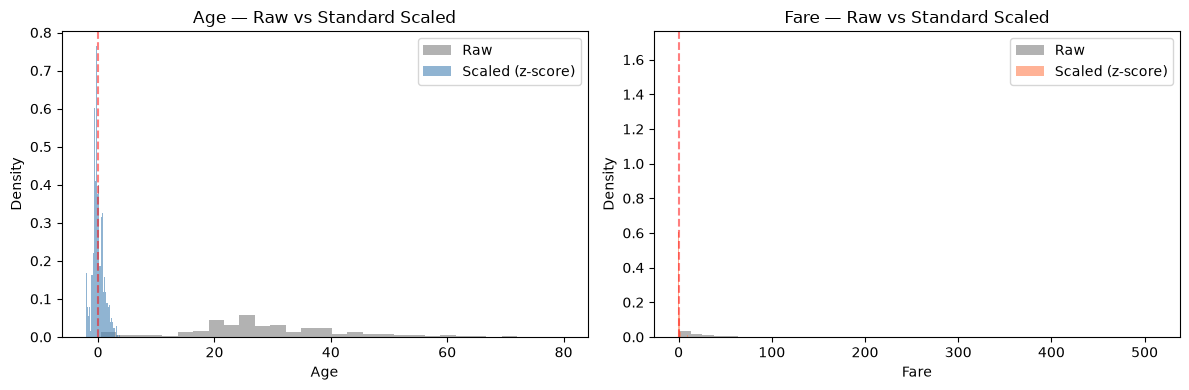

In [22]:
# Demonstrate scaling on Titanic's numeric features
scaler = StandardScaler()
titanic_num = titanic[["age", "fare", "sibsp", "parch"]]
scaled = scaler.fit_transform(titanic_num)

scaled_df = pd.DataFrame(
    scaled,
    columns=[f"{c}_scaled" for c in ["age", "fare", "sibsp", "parch"]],
    index=titanic_num.index,
)

print("=" * 60)
print("Standard Scaling — Numeric Features (Titanic)")
print("=" * 60)
print(f"{'Feature':<12s}  {'Before':>20s}  {'After (z-score)':>20s}")
print(f"{'':-<12s}  {'':->20s}  {'':->20s}")
for col in ["age", "fare", "sibsp", "parch"]:
    raw = titanic[col]
    sc = scaled_df[f"{col}_scaled"]
    print(f"{col:<12s}  mean={raw.mean():>8.2f} std={raw.std():>8.2f}    "
          f"mean={sc.mean():>8.2f} std={sc.std():>8.2f}")

# Visualise before vs after for age and fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age
axes[0].hist(titanic["age"], bins=30, alpha=0.6, density=True,
             label="Raw", color="gray")
axes[0].hist(scaled_df["age_scaled"], bins=30, alpha=0.6, density=True,
             label="Scaled (z-score)", color="steelblue")
axes[0].axvline(0, color="red", ls="--", alpha=0.5)
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Density")
axes[0].set_title("Age — Raw vs Standard Scaled")
axes[0].legend()

# Fare
axes[1].hist(titanic["fare"], bins=40, alpha=0.6, density=True,
             label="Raw", color="gray")
axes[1].hist(scaled_df["fare_scaled"], bins=40, alpha=0.6, density=True,
             label="Scaled (z-score)", color="coral")
axes[1].axvline(0, color="red", ls="--", alpha=0.5)
axes[1].set_xlabel("Fare"); axes[1].set_ylabel("Density")
axes[1].set_title("Fare — Raw vs Standard Scaled")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Combined Preprocessor (ColumnTransformer)

The three transforms are composed into a single **ColumnTransformer** that
applies the right transform to each column automatically:

| Transform | Columns |
|-----------|---------|
| `StandardScaler()` | age, fare, sibsp, parch |
| `OneHotEncoder(drop='first')` | sex, embarked, adult_minor, passenger_crew |
| `OrdinalEncoder` | class |

This can be `fit_transform`'d in one call and serialised for later use on
new/unseen data.

In [23]:
from feature_pipeline import build_combined_preprocessor, get_feature_names

# Build preprocessor for Titanic
titanic_ct = build_combined_preprocessor(
    numeric_cols=COMMON_NUMERIC + TITANIC_NUMERIC,
    onehot_cols=[c for c in COMMON_CATEGORICAL + TITANIC_CATEGORICAL
                 if c not in COMMON_CATEGORICAL_ORDINAL],
    ordinal_cols=COMMON_CATEGORICAL_ORDINAL,
)

# Extract feature matrix and target from Titanic
y_titanic = titanic[TARGET].values
all_feature_cols = (
    COMMON_NUMERIC + TITANIC_NUMERIC
    + [c for c in COMMON_CATEGORICAL + TITANIC_CATEGORICAL
       if c not in COMMON_CATEGORICAL_ORDINAL]
    + COMMON_CATEGORICAL_ORDINAL
)
X_titanic_raw = titanic[all_feature_cols]

# Fit and transform in one call
X_titanic = titanic_ct.fit_transform(X_titanic_raw)
feature_names = get_feature_names(titanic_ct, X_titanic_raw)
X_titanic_df = pd.DataFrame(X_titanic, columns=feature_names, index=X_titanic_raw.index)

print("=" * 60)
print("Combined Preprocessor — Titanic")
print("=" * 60)
print(f"\nRaw feature columns ({len(all_feature_cols)}):")
print(f"  Numeric (scaled):  {COMMON_NUMERIC + TITANIC_NUMERIC}")
print(f"  One-hot encoded:   {[c for c in COMMON_CATEGORICAL + TITANIC_CATEGORICAL if c not in COMMON_CATEGORICAL_ORDINAL]}")
print(f"  Ordinal encoded:   {COMMON_CATEGORICAL_ORDINAL}")

print(f"\nEncoded feature matrix ({len(feature_names)} columns):")
print(f"  {feature_names}")
print(f"\nShape: {X_titanic_df.shape}")
print(f"\nFirst 10 rows of encoded feature matrix:")
X_titanic_df.head(10)

Combined Preprocessor — Titanic

Raw feature columns (7):
  Numeric (scaled):  ['age', 'fare', 'sibsp', 'parch']
  One-hot encoded:   ['sex', 'embarked']
  Ordinal encoded:   ['class']

Encoded feature matrix (8 columns):
  ['age', 'fare', 'sibsp', 'parch', 'sex_male', 'embarked_Q', 'embarked_S', 'class']

Shape: (889, 8)

First 10 rows of encoded feature matrix:


,age,fare,sibsp,parch,sex_male,embarked_Q,embarked_S,class
0,-0.532730,-0.500240,0.431350,-0.474326,1.0,0.0,1.0,2.0
1,0.673661,0.788947,0.431350,-0.474326,0.0,0.0,0.0,0.0
2,-0.231132,-0.486650,-0.475199,-0.474326,0.0,0.0,1.0,2.0
3,0.447463,0.422861,0.431350,-0.474326,0.0,0.0,1.0,0.0
4,0.447463,-0.484133,-0.475199,-0.474326,1.0,0.0,1.0,2.0
5,-0.306531,-0.475913,-0.475199,-0.474326,1.0,1.0,0.0,2.0
6,1.880053,0.397946,-0.475199,-0.474326,1.0,0.0,1.0,0.0
7,-2.040719,-0.221900,2.244449,0.765897,1.0,0.0,1.0,2.0
8,-0.155733,-0.422057,-0.475199,2.006119,0.0,0.0,1.0,2.0
9,-1.135925,-0.040787,0.431350,-0.474326,0.0,0.0,0.0,1.0


## 7. Stratified Train/Test Split

The encoded features are split into training (80%) and testing (20%) sets using
**stratified sampling** — the survival rate in both splits matches the original
dataset (~38%).

**Why stratified?** Our target is imbalanced (only ~38% survived). A random split
could, by chance, produce a test set with 30% or 45% survival, giving misleading
performance metrics. Stratification ensures both splits have the same class
proportion as the full dataset.

Train/Test Split — Titanic

Total:      889 rows  (survival=38.2%)
Train:      711 rows  (80%)  survival=38.3%
Test:       178 rows  (20%)  survival=38.2%


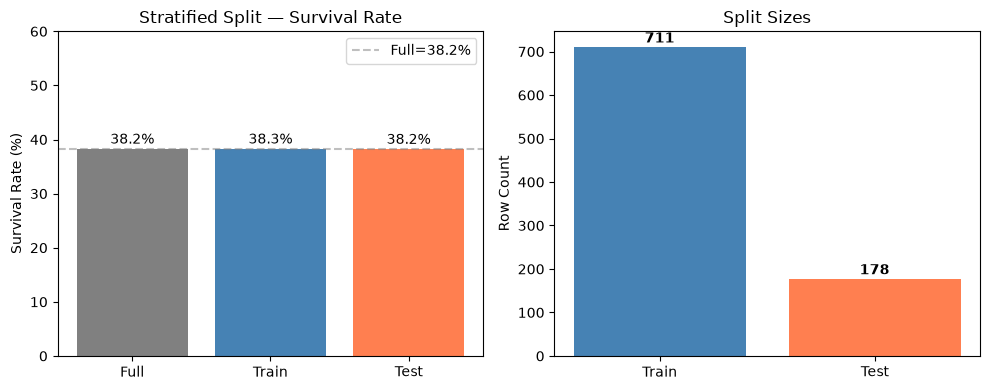


Training feature matrix (first 8 rows):


,age,fare,sibsp,parch,sex_male,embarked_Q,embarked_S,class
620,0.975259,0.411872,0.431350,-0.474326,1.0,0.0,1.0,0.0
480,0.070466,-0.646204,-0.475199,-0.474326,1.0,0.0,1.0,1.0
526,0.824460,3.818890,-0.475199,-0.474326,1.0,0.0,1.0,0.0
434,-1.135925,1.769763,0.431350,2.006119,0.0,0.0,1.0,0.0
796,0.145865,-0.471383,-0.475199,-0.474326,0.0,0.0,1.0,2.0
651,-0.608129,-0.476416,-0.475199,-0.474326,1.0,0.0,1.0,2.0
310,-0.834328,4.636208,1.337900,2.006119,0.0,0.0,0.0,0.0
556,0.824460,3.934570,-0.475199,-0.474326,1.0,0.0,0.0,0.0


In [24]:
from feature_pipeline import stratified_split

X_train, X_test, y_train, y_test = stratified_split(X_titanic_df, y_titanic)

print("=" * 60)
print("Train/Test Split — Titanic")
print("=" * 60)
print(f"\nTotal:     {len(X_titanic_df):>4d} rows  (survival={y_titanic.mean()*100:.1f}%)")
print(f"Train:     {len(X_train):>4d} rows  ({len(X_train)/len(X_titanic_df)*100:.0f}%)  "
      f"survival={y_train.mean()*100:.1f}%")
print(f"Test:      {len(X_test):>4d} rows  ({len(X_test)/len(X_titanic_df)*100:.0f}%)  "
      f"survival={y_test.mean()*100:.1f}%")

# Visualise the class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Survival rate comparison
bars = axes[0].bar(["Full", "Train", "Test"],
                   [y_titanic.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
                   color=["gray", "steelblue", "coral"])
axes[0].axhline(y_titanic.mean() * 100, color="gray", ls="--", alpha=0.5,
                label=f"Full={y_titanic.mean()*100:.1f}%")
axes[0].set_ylabel("Survival Rate (%)"); axes[0].set_ylim(0, 60)
axes[0].set_title("Stratified Split — Survival Rate")
for bar, val in zip(bars, [y_titanic.mean() * 100, y_train.mean() * 100, y_test.mean() * 100]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.1f}%", ha="center", fontsize=10)
axes[0].legend()

# Sample sizes
axes[1].bar(["Train", "Test"], [len(y_train), len(y_test)],
            color=["steelblue", "coral"])
axes[1].set_ylabel("Row Count"); axes[1].set_title("Split Sizes")
for i, v in enumerate([len(y_train), len(y_test)]):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTraining feature matrix (first 8 rows):")
X_train.head(8)

## 8. All Three Scenarios

Run the full feature pipeline for all three scenarios and compare the results.

> **Note:** This calls the same `run_scenario()` function from
> `feature_pipeline.py` that the CLI uses, so the notebook stays in sync
> with the script.

In [25]:
# --- Build scenarios and run them via the script's own function ---

# 1. Titanic
titanic_onehot = [c for c in COMMON_CATEGORICAL + TITANIC_CATEGORICAL
                  if c not in COMMON_CATEGORICAL_ORDINAL]
scenarios = [
    ("Titanic", titanic, COMMON_NUMERIC + TITANIC_NUMERIC,
     titanic_onehot, COMMON_CATEGORICAL_ORDINAL),
]

# 2. Lusitania
lusitania_onehot = [c for c in COMMON_CATEGORICAL + LUSITANIA_CATEGORICAL
                    if c not in COMMON_CATEGORICAL_ORDINAL]
scenarios.append(
    ("Lusitania", lusitania, COMMON_NUMERIC,
     lusitania_onehot, COMMON_CATEGORICAL_ORDINAL)
)

# 3. Pooled (common features only)
common_features = list(
    set(COMMON_NUMERIC + COMMON_CATEGORICAL)
    & set(titanic.columns) & set(lusitania.columns)
)
common_numeric = [c for c in COMMON_NUMERIC if c in common_features]
common_onehot = [c for c in COMMON_CATEGORICAL if c not in COMMON_CATEGORICAL_ORDINAL]
common_ordinal = [c for c in COMMON_CATEGORICAL if c in COMMON_CATEGORICAL_ORDINAL]
common_onehot = [c for c in common_onehot if c not in (common_ordinal or [])]

cols_to_concat = common_features + [TARGET]
tit_common = titanic[cols_to_concat].copy()
lus_common = lusitania[[c for c in cols_to_concat if c in lusitania.columns]].copy()
pooled_df = pd.concat([tit_common, lus_common], ignore_index=True)

scenarios.append(("Pooled", pooled_df, common_numeric, common_onehot, common_ordinal))

# Run each scenario
results = []
for name, df, num_cols, oh_cols, ord_cols in scenarios:
    print(f"\n{'=' * 60}")
    print(f"  Running: {name}")
    print(f"{'=' * 60}")
    r = run_scenario(
        name=name, df=df,
        numeric_cols=num_cols,
        onehot_cols=oh_cols,
        ordinal_cols=ord_cols,
    )
    results.append(r)

# Summary table
print(f"\n{'=' * 60}")
print("  Scenario Summary")
print(f"{'=' * 60}")
summary_rows = []
for r in results:
    summary_rows.append({
        "Scenario": r["name"],
        "Total Rows": len(r["X_train"]) + len(r["X_test"]),
        "Train": len(r["X_train"]),
        "Test": len(r["X_test"]),
        "Features": len(r["feature_names"]),
        "Train Surv.": f"{r['y_train'].mean()*100:.1f}%",
        "Test Surv.": f"{r['y_test'].mean()*100:.1f}%",
        "Feature Names": ", ".join(r["feature_names"]),
    })

pd.DataFrame(summary_rows).style.set_properties(**{'text-align': 'left'})


  Running: Titanic

------------------------------------------------------------
  Scenario: Titanic
  Rows: 889
------------------------------------------------------------
  Target:  340/889 survived (38.2%)
  Raw features (7): ['age', 'fare', 'sibsp', 'parch', 'sex', 'embarked', 'class']
    [num]  age                   mean=   29.07  std=   13.27
    [num]  fare                  mean=   32.10  std=   49.70
    [num]  sibsp                 mean=    0.52  std=    1.10
    [num]  parch                 mean=    0.38  std=    0.81
    [oh]   sex                   categories=['male', 'female']
    [oh]   embarked              categories=['S', 'C', 'Q']
    [ord]  class                 categories=['Third', 'First', 'Second']
  Encoded features (8): ['age', 'fare', 'sibsp', 'parch', 'sex_male', 'embarked_Q', 'embarked_S', 'class']

  Train: 711 rows  (survival=38.3%)
  Test:  178 rows  (survival=38.2%)

  Running: Lusitania

------------------------------------------------------------
  S

,Scenario,Total Rows,Train,Test,Features,Train Surv.,Test Surv.,Feature Names
0,Titanic,889,711,178,8,38.3%,38.2%,"age, fare, sibsp, parch, sex_male, embarked_Q, embarked_S, class"
1,Lusitania,1953,1562,391,6,39.2%,39.1%,"age, sex_male, adult_minor_Infant, adult_minor_Minor, passenger_crew_Passenger, class"
2,Pooled,2842,2273,569,3,38.9%,38.8%,"age, sex_male, class"


## 9. Summary

### Pipeline steps

| # | Step | Transform | Applied to |
|---|------|-----------|------------|
| 1 | **One-hot encode** | `OneHotEncoder(drop='first')` | sex, embarked, adult_minor, passenger_crew |
| 2 | **Ordinal encode** | `OrdinalEncoder(["First","Second","Third"])` | class (unknown -> -1) |
| 3 | **Standard scale** | `StandardScaler()` | age, fare, sibsp, parch |
| 4 | **ColumnTransformer** | Combines all 3 transforms in parallel | All feature columns in one call |
| 5 | **Stratified split** | 80/20 train/test with `stratify=y` | Encoded feature matrix |

### Output files (saved to `processed/`)

```
processed/X_train_titanic.parquet    processed/y_train_titanic.npy
processed/X_test_titanic.parquet     processed/y_test_titanic.npy
processed/X_train_lusitania.parquet  processed/y_train_lusitania.npy
processed/X_test_lusitania.parquet   processed/y_test_lusitania.npy
processed/X_train_pooled.parquet     processed/y_train_pooled.npy
processed/X_test_pooled.parquet      processed/y_test_pooled.npy
```

### Key takeaways

- **Sex** is binary after encoding: `sex_male` (0 = female, 1 = male)
- **Class** is ordinal: First=0, Second=1, Third=2 (Lusitania unknowns -> -1)
- **Age, fare, sibsp, parch** are z-score scaled (mean=0, std=1)
- **Stratified split** preserves ~38% survival in both train and test sets
- The **ColumnTransformer** can be saved and re-used on new/unseen data
- Three scenarios support running models on Titanic-only, Lusitania-only, or pooled common features

### Next steps

The processed data is ready for model training. A `base_model.py` script can
load these parquet/npy files and start fitting classifiers — using all features
per dataset or just the common features for cross-disaster comparison.